In [64]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import torch;
print(torch.__version__)
# add parent folder (production) to sys.path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from utils.LoRa import LoRa, MultiBAM

import importlib
import utils.my_lora_utils
importlib.reload(utils.my_lora_utils)
from utils.my_lora_utils import *

print(utils.my_lora_utils.__file__)

2.7.1+cpu
c:\Users\priba\Sean-2025\INC-LAB\BAM\INC-BAM\utils\my_lora_utils.py


(4096,)
(512, 33)
[[ 3.92858329e-03 -2.79641017e-07  2.54985452e-05 ...  2.54985452e-05
  -2.79641017e-07 -3.88391671e-03]
 [-1.91055173e-02  7.30648583e-07 -1.07942270e-04 ...  1.34439447e-04
  -1.03039628e-06 -2.02782046e-02]
 [-3.84641210e-03 -1.88782331e-07  1.92861508e-05 ...  3.44357525e-05
  -4.25987250e-07  3.99496064e-03]
 ...
 [-2.18375472e-02  1.49168501e-06 -1.70445017e-04 ...  8.80000874e-05
  -5.29974975e-07 -1.79028159e-02]
 [-3.81753936e-03 -4.25987251e-07  3.44357525e-05 ...  1.92861508e-05
  -1.88782331e-07  3.96608790e-03]
 [ 2.02782046e-02  1.03039628e-06 -1.34439447e-04 ...  1.07942270e-04
  -7.30648589e-07  1.91055173e-02]]
torch.Size([4096, 33])


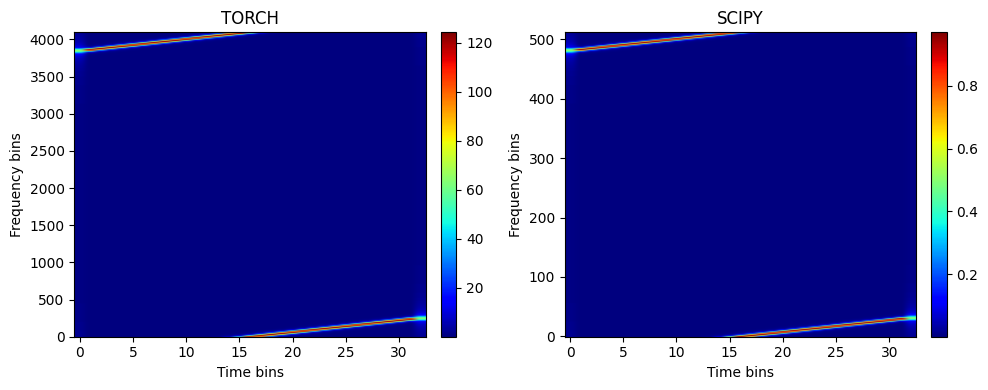

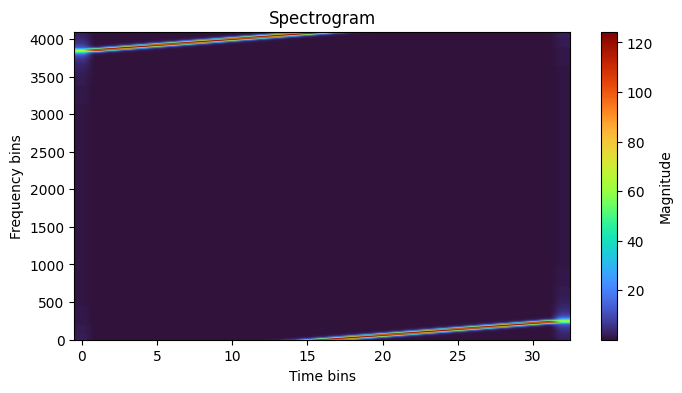

In [66]:
# ---- Example usage with your LoRa generator ----
sf = 9
bw = 125000
fs = 1_000_000
lora_init = LoRa(sf, bw)
x1 = lora_init.gen_symbol_fs(0, sf, bw, down=False, Fs=fs) # you had Fs=int(bw*8)=1e6
print(x1.shape)
a,b,asa,ds,ds,ds =create_spectrogram_npy_dual(x1,fs,0,0,0,None,None)
print(a)
x= create_spectrogram_from_torch(x1)
print(x.shape)
magnitude = np.sqrt(a**2 + b**2)
mag_db = 20 * np.log10(magnitude + 1e-9)

show_multiple_spectrograms([torch.abs(x).numpy(),magnitude],["TORCH","SCIPY"],2)

import matplotlib.pyplot as plt
import numpy as np
S = torch.abs(x).numpy()
plt.figure(figsize=(8,4))
plt.imshow(
    S, 
    aspect='auto', 
    origin='lower',        # LOW FREQUENCY at bottom (correct orientation)
    cmap='turbo'           # or 'viridis'
)
plt.colorbar(label='Magnitude')
plt.xlabel("Time bins")
plt.ylabel("Frequency bins")
plt.title("Spectrogram")
plt.show()


torch.Size([1024, 33])
torch.Size([1, 2, 512, 33])
tensor([[[ 6.1402e+01,  1.3419e+00,  2.3095e+00,  ...,  1.5218e-04,
          -8.4498e-07, -4.9971e-01],
         [-6.2531e+01,  8.3230e-01, -4.2564e+00,  ..., -1.5118e-04,
          -2.6920e-04,  4.9972e-01],
         [ 6.3373e+01, -3.0817e+00,  6.5027e+00,  ...,  1.4432e-04,
           5.3213e-04, -4.9976e-01],
         ...,
         [-5.0018e-01, -7.7841e-04, -1.3193e-04,  ..., -9.0556e+00,
           5.3751e+00, -6.2914e+01],
         [ 5.0024e-01,  5.3288e-04,  1.4453e-04,  ...,  6.5027e+00,
          -3.0817e+00,  6.2373e+01],
         [-5.0028e-01, -2.6997e-04, -1.5142e-04,  ..., -4.2564e+00,
           8.3231e-01, -6.1531e+01]],

        [[ 1.2424e+01,  6.6318e+01, -1.2234e+01,  ..., -3.4104e-07,
          -1.3261e-04, -1.2077e+00],
         [-9.0070e+00, -7.1714e+01,  1.2940e+01,  ..., -2.9784e-04,
           1.3168e-04,  1.2102e+00],
         [ 5.4722e+00,  7.7060e+01, -1.3511e+01,  ...,  5.8829e-04,
          -1.2560e-04, -1

C:\Users\priba\AppData\Local\Temp\ipykernel_10276\2030329860.py:29: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mag = np.abs(real_part + im_part * 1j)
C:\Users\priba\AppData\Local\Temp\ipykernel_10276\2030329860.py:33: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  mags = np.abs(real_parts + im_parts * 1j)


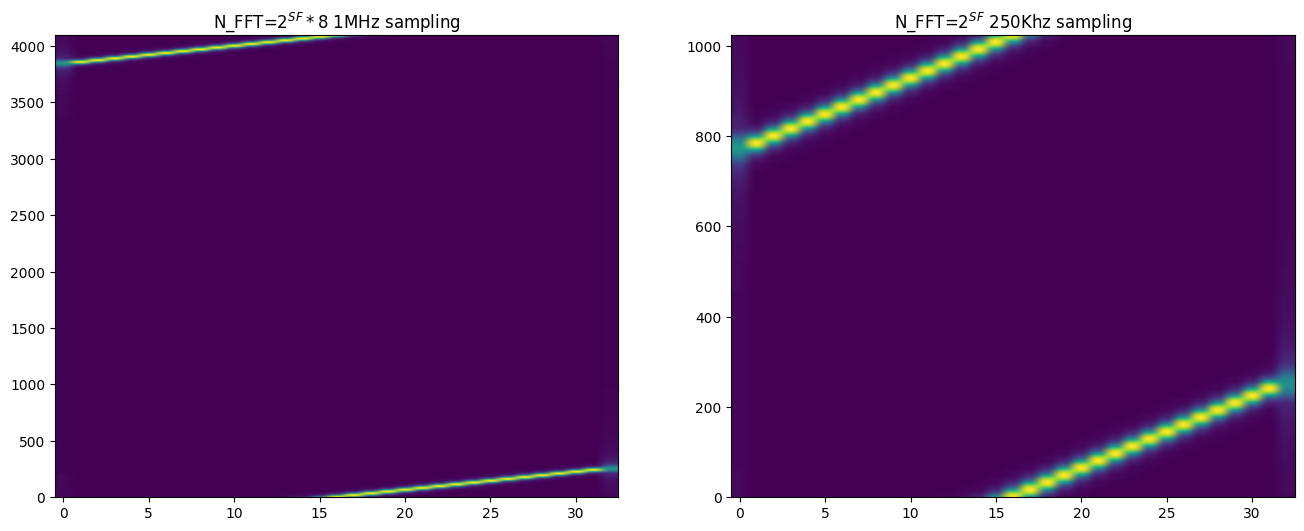

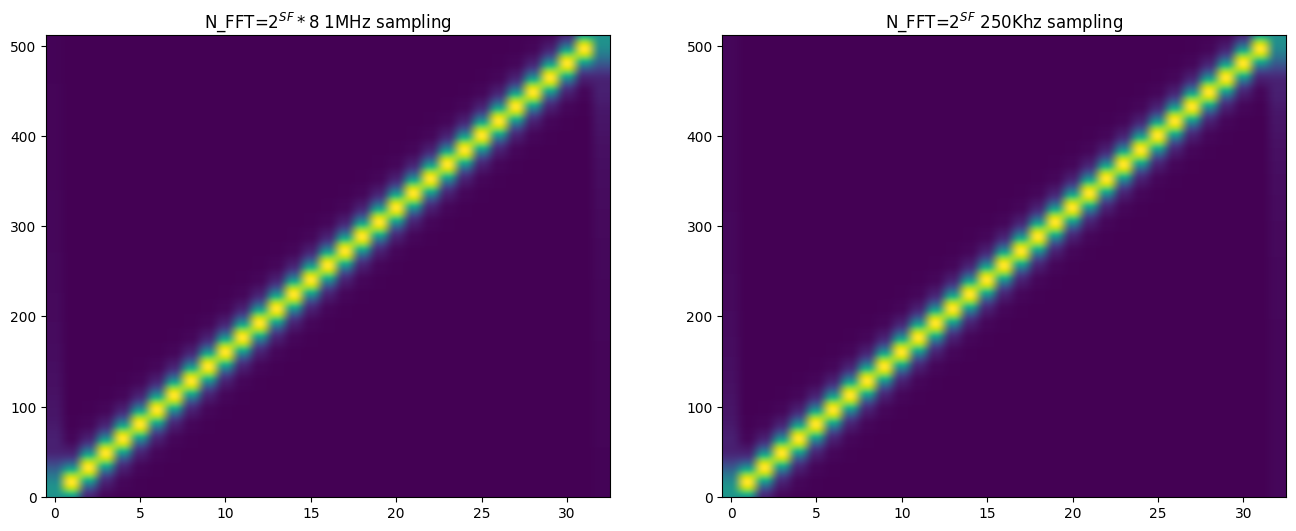

In [73]:
# ---- Example usage with your LoRa generator ----
sf = 9
bw = 125000
fs = 1_000_000
fs2 = 250_000
lora_init = LoRa(sf, bw)
x1 = lora_init.gen_symbol_fs(0, sf, bw, down=False, Fs=fs) # you had Fs=int(bw*8)=1e6
x2 = lora_init.gen_symbol_fs(0, sf, bw, down=False, Fs=fs2) # you had Fs=int(bw*8)=1e6
x= create_spectrogram_from_torch(x1)
x_sean = create_spectrogram_from_torch_sean(x2)

print(x_sean.shape)
# Add batch dimension → (1, 128, 512)
spec = np.expand_dims(x, axis=0)
# Convert to torch complex tensor
spec = torch.tensor(spec, dtype=torch.complex64)

# Convert to torch complex tensor
spec_sean = np.expand_dims(x_sean, axis=0)
spec_sean = torch.tensor(spec_sean, dtype=torch.complex64)

output = spec_to_network_input(spec)
output_sean = spec_to_network_input(spec_sean)
print(output.shape)
print(output[0])

real_part = output[0][0]
im_part = output[0][1]
mag = np.abs(real_part + im_part * 1j)

real_parts = output_sean[0][0]
im_parts = output_sean[0][1]
mags = np.abs(real_parts + im_parts * 1j)
plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.title('N_FFT=$2^{SF} * 8$ 1MHz sampling')
plt.imshow(torch.abs(x),origin='lower',aspect='auto')
plt.subplot(1,2,2)
plt.title('N_FFT=$2^{SF}$ 250Khz sampling')
plt.imshow(torch.abs(x_sean),origin='lower',aspect='auto')


plt.figure(figsize=(16,6))
plt.subplot(1,2,1)
plt.title('N_FFT=$2^{SF} * 8$ 1MHz sampling')
plt.imshow(mag,origin='lower',aspect='auto')
plt.subplot(1,2,2)
plt.title('N_FFT=$2^{SF}$ 250Khz sampling')
plt.imshow(mags,origin='lower',aspect='auto')
plt.show()

torch.Size([257, 33])


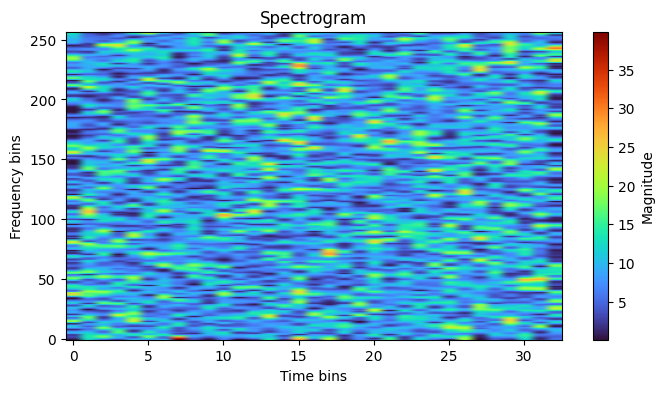

In [ ]:
# Generate a simple audio signal
signal = torch.randn(4096)
 
# Compute the STFT
stft = torch.stft(signal, n_fft=512, hop_length=128, win_length=256, window=torch.hamming_window(256),return_complex=True)
 
print(stft.shape)

S = torch.abs(stft).numpy()
plt.figure(figsize=(8,4))
plt.imshow(
    S, 
    aspect='auto', 
    origin='lower',        # LOW FREQUENCY at bottom (correct orientation)
    cmap='turbo'           # or 'viridis'
)
plt.colorbar(label='Magnitude')
plt.xlabel("Time bins")
plt.ylabel("Frequency bins")
plt.title("Spectrogram")
plt.show()